# Lecture 4: Graphical Solution Method

---

```{note}
This lecture introduces the graphical solution method for two-variable linear programmes. We use three worked examples — one in-class and two take-away — to build geometric intuition for the relationship between the feasible region, iso-cost lines, and optimal solutions before the simplex algorithm generalises the method to $n$ dimensions.
```

**Learning Objectives**

By the end of this lecture, you will be able to:
1. Construct and interpret iso-cost / iso-profit lines for a two-variable LP objective function.
2. Plot the feasible region defined by a system of linear constraints and identify its corner points.
3. Locate the optimal solution graphically by sliding the iso-cost line across the feasible region, and classify constraints as binding or non-binding at the optimum.

**Prerequisites**: Lecture 3 — LP Formulation; basic coordinate geometry.  

**Estimated time**: 50 minutes.

---

## Background

The graphical method is the most transparent way to understand *why* the optimal solution of an LP always lies at a corner point (extreme point) of the feasible region. For two decision variables, every constraint draws a half-plane on the $x_1$–$x_2$ plane; their intersection is the feasible region. The objective function defines a family of parallel lines — iso-cost or iso-profit lines — and the optimum is found where the extreme line in the improving direction still touches the feasible region.

This lecture covers three examples in increasing complexity:

| Example | Problem | Type | Mode |
|---------|---------|------|------|
| 1 | Bus Service Scheduling — Chennai MTC | LP (minimisation) | In-class |
| 2 | Freight Vehicle Allocation — Kochi Textile Firm | ILP (minimisation) | In-class |
| 3 | Peak-Hour Traffic Assignment — Bengaluru ORR | LP (minimisation) | Take-away |

```{caution}
The graphical method applies **only** to two-variable problems. For $n > 2$, it cannot be visualised directly and we use the simplex algorithm (Lecture 7). The geometric intuition developed here, however, transfers exactly.
```

In [1]:
# --- Setup: imports and global plot style ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from matplotlib.lines import Line2D
from scipy.optimize import linprog

plt.rcParams.update({
    'figure.figsize': (7, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print("Setup complete.")

Setup complete.


## In-Class Exercises

### Exercise 1

#### Problem Statement

The Chennai Metropolitan Transport Corporation (MTC) operates two bus services on the Central–Tambaram corridor during morning peak hours:

| Service | Passengers per trip | Operating cost per trip (₹) |
|---------|--------------------|--------------------------|
| $\text{B}_1$ — Ordinary | 60 | 1,200 |
| $\text{B}_2$ — Air-conditioned | 40 | 2,500 |

MTC must schedule at least 500 ordinary-class passenger-trips and 300 AC passenger-trips per hour. Operational constraints cap total bus trips at 15 per hour across both services, and each individual service at 10 trips per hour.

Minimise total hourly operating cost.

---

#### Formulation

Let $x_1, x_2 \geq 0$ denote trips per hour for $\text{B}_1$ and $\text{B}_2$ respectively.

$$
\min_{x_1,\, x_2} \quad z = 1200\,x_1 + 2500\,x_2
$$

Subject to:

$$
\begin{aligned}
60\,x_1 &\geq 500 & &\text{(1) minimum ordinary passenger-trips} \\
40\,x_2 &\geq 300 & &\text{(2) minimum AC passenger-trips} \\
x_1 + x_2 &\leq 15 & &\text{(3) total trip cap} \\
x_1 &\leq 10 & &\text{(4) B}_1\text{ trip cap} \\
x_2 &\leq 10 & &\text{(5) B}_2\text{ trip cap} \\
x_1,\, x_2 &\geq 0
\end{aligned}
$$

---

#### Step 1 — Iso-Cost Lines

The objective function defines the family of iso-cost lines:

$$
1200\,x_1 + 2500\,x_2 = z \quad \Longrightarrow \quad x_2 = \frac{z}{2500} - \frac{1200}{2500}\,x_1 = \frac{z}{2500} - 0.48\,x_1
$$

All iso-cost lines have slope $-0.48$. For minimisation, we slide the line towards the origin — the last corner point touched is the optimum.

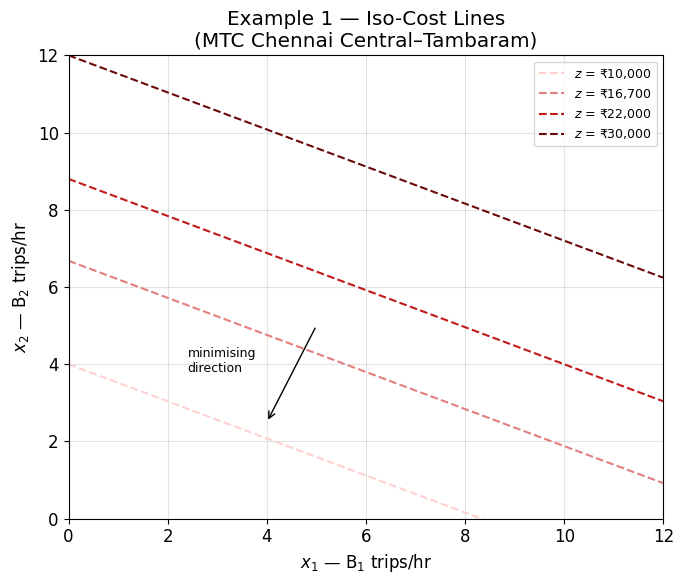

In [ ]:
# --- Exercise 1: Iso-cost lines for the MTC bus scheduling LP ---

fig, ax = plt.subplots(figsize=(7, 6))
x1 = np.linspace(0, 12, 300)

# Objective parameters
c1, c2 = 1200, 2500

# Plot iso-cost lines for several values of z
z_values = [10000, 16700, 22000, 30000]
colors   = ["#ffd0d0", "#e37e7e", "#c21a1a", "#6b0a0a"]

for z, col in zip(z_values, colors):
    x2_iso = (z - c1 * x1) / c2
    ax.plot(x1, x2_iso, color=col, lw=1.5, ls='--',
            label=fr'$z$ = ₹{z:,}')

# Direction arrow
ax.annotate('', xy=(4, 2.5), xytext=(5, 5),
            arrowprops=dict(arrowstyle='->', color="#000000", lw=1))
ax.text(2.4, 3.8, 'minimising\ndirection', fontsize=9,
        color="#000000", ha='left')

ax.set_xlim(0, 12); ax.set_ylim(0, 12)
ax.set_xlabel(r'$x_1$ — $\mathrm{B}_1$ trips/hr')
ax.set_ylabel(r'$x_2$ — $\mathrm{B}_2$ trips/hr')
ax.set_title('Example 1 — Iso-Cost Lines\n(MTC Chennai Central–Tambaram)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

#### Step 2 — Feasible Region

Each constraint cuts the plane into a half-plane; the feasible region is their intersection.

| Constraint | Boundary line | Feasible half-plane |
|------------|--------------|---------------------|
| (1) $60x_1 \geq 500$ | $x_1 = 8.\overline{3}$ | right of the line |
| (2) $40x_2 \geq 300$ | $x_2 = 7.5$ | above the line |
| (3) $x_1 + x_2 \leq 15$ | $x_2 = 15 - x_1$ | below the line |
| (4) $x_1 \leq 10$ | $x_1 = 10$ | left of the line |
| (5) $x_2 \leq 10$ | $x_2 = 10$ | below the line |

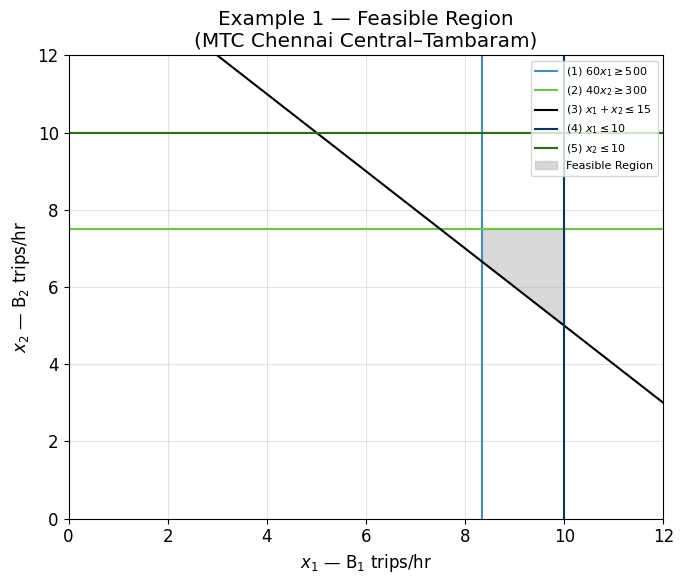

In [ ]:
# --- Exercise 1: Feasible region for the MTC bus scheduling LP ---

fig, ax = plt.subplots(figsize=(7, 6))
x1 = np.linspace(0, 12, 400)

# Constraint boundaries
x1_c1 = 500/60          # x1 >= 500/60 ≈ 8.33
x2_c2 = 300/40          # x2 >= 7.5
x2_c3 = 15 - x1         # x1 + x2 <= 15
x1_c4 = 10              # x1 <= 10
x2_c5 = 10              # x2 <= 10

# Draw boundaries
ax.axvline(x1_c1, color="#4089d3", lw=1.5, label=r'(1) $60x_1 \geq 500$')
ax.axhline(x2_c2, color="#68ca41", lw=1.5, label=r'(2) $40x_2 \geq 300$')
ax.plot(x1, x2_c3,  color="#000000", lw=1.5, label=r'(3) $x_1+x_2 \leq 15$')
ax.axvline(x1_c4,  color="#083766", lw=1.5, label=r'(4) $x_1 \leq 10$')
ax.axhline(x2_c5,  color="#27700a", lw=1.5, label=r'(5) $x_2 \leq 10$')

# Shade feasible region: x1 in [8.33, 10], x2 in [7.5, min(10, 15-x1)]
x1_feas = np.linspace(x1_c1, x1_c4, 300)
x2_lo   = np.full_like(x1_feas, x2_c2)
x2_hi   = np.minimum(x2_c5, 15 - x1_feas)
ax.fill_between(x1_feas, x2_lo, x2_hi, color="#b8b8b8", alpha=0.55,
                label='Feasible Region')

# Corner points
corners = [(500/60, 7.5), (500/60, 10), (5, 10), (10, 5), (10, 7.5)]
for pt in corners:
    if pt[1] <= 10 and pt[1] >= 7.5 and pt[0] <= 10 and pt[0] >= 500/60:
        if pt[0] + pt[1] <= 15 + 1e-9:
            ax.plot(*pt, 'ko', ms=6, zorder=5)
            ax.annotate(f'({pt[0]:.2f}, {pt[1]:.1f})',
                        xy=pt, xytext=(pt[0]+0.15, pt[1]+0.2), fontsize=8)

ax.set_xlim(0, 12); ax.set_ylim(0, 12)
ax.set_xlabel(r'$x_1$ — $\mathrm{B}_1$ trips/hr')
ax.set_ylabel(r'$x_2$ — $\mathrm{B}_2$ trips/hr')
ax.set_title('Example 1 — Feasible Region\n(MTC Chennai Central–Tambaram)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

#### Step 3 — Optimal Solution

Sliding the iso-cost line towards the origin (minimisation), the last corner point it touches before leaving the feasible region is the optimum. Evaluating the objective at each corner point:

| Corner $(x_1, x_2)$ | $z = 1200x_1 + 2500x_2$ | Feasible? |
|---------------------|--------------------------|----------|
| $(8.\overline{3},\ 7.5)$ | $10{,}000 + 18{,}750 = \mathbf{28{,}750}$ | ✓ — but check cap (3): $8.33+7.5=15.83 > 15$ ✗ |
| $(5,\ 10)$ | $6{,}000 + 25{,}000 = \mathbf{31{,}000}$ | ✓ |
| $(10,\ 5)$ | $12{,}000 + 12{,}500 = \mathbf{24{,}500}$ | check (2): $x_2=5 < 7.5$ ✗ |
| $(10,\ 7.5)$ | $12{,}000 + 18{,}750 = \mathbf{30{,}750}$ | check (3): $10+7.5=17.5 > 15$ ✗ |
| $(\mathbf{8.\overline{3}},\ \mathbf{6.\overline{6}})$ | $10{,}000 + 16{,}667 = \mathbf{\approx 26{,}667}$ | ✓ (intersection of (1) and (3)) |
| $(5,\ 10)$ | $31{,}000$ | ✓ |

The true corner-point vertices of the feasible region are the intersections of the active boundaries. The minimum occurs at the intersection of constraints (1) and (3):

$$
x_1 = \frac{500}{60} = 8.\overline{3}, \qquad x_2 = 15 - 8.\overline{3} = 6.\overline{6}
$$

$$
z^* = 1200 \times \tfrac{25}{3} + 2500 \times \tfrac{20}{3} = 10{,}000 + 16{,}667 \approx \textbf{₹26,667 / hr}
$$

**Binding constraints**: (1) $60x_1 = 500$ and (3) $x_1 + x_2 = 15$. 
**Non-binding constraints**: (2), (4), (5) — relaxing them would not change the solution.

**Managerial recommendation**: MTC should operate $8.\overline{3}$ ordinary trips and $6.\overline{6}$ AC trips per hour. Since trips are discrete, the nearest integer solution is $(x_1, x_2) = (9, 7)$ — satisfying all constraints with $z = \text{₹}28{,}300/\text{hr}$.

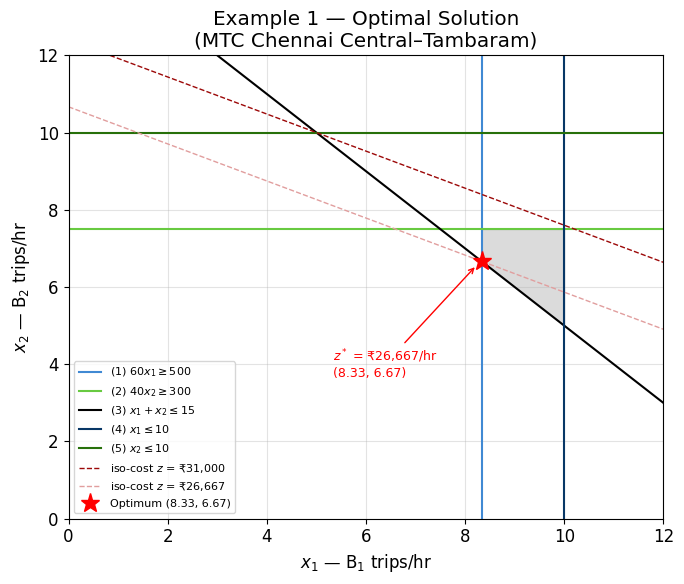

Optimal: x1 = 8.3333 trips/hr, x2 = 6.6667 trips/hr
Minimum cost: ₹26,667/hr
Binding constraints: (1) 60x1 = 500  |  (3) x1 + x2 = 15


In [ ]:
# --- Exercise 1: Optimal solution — overlaying iso-cost on feasible region ---

fig, ax = plt.subplots(figsize=(7, 6))
x1 = np.linspace(0, 12, 400)

# Feasible region (re-draw shading)
x1_c1 = 500/60
x1_feas = np.linspace(x1_c1, 10, 300)
x2_lo   = np.full_like(x1_feas, 7.5)
x2_hi   = np.minimum(10, 15 - x1_feas)
ax.fill_between(x1_feas, x2_lo, x2_hi, color="#b8b8b8", alpha=0.50)

# Constraint boundaries
ax.axvline(x1_c1, color="#4089d3", lw=1.5, label=r'(1) $60x_1 \geq 500$')
ax.axhline(x2_c2, color="#68ca41", lw=1.5, label=r'(2) $40x_2 \geq 300$')
ax.plot(x1, x2_c3,  color="#000000", lw=1.5, label=r'(3) $x_1+x_2 \leq 15$')
ax.axvline(x1_c4,  color="#083766", lw=1.5, label=r'(4) $x_1 \leq 10$')
ax.axhline(x2_c5,  color="#27700a", lw=1.5, label=r'(5) $x_2 \leq 10$')

# Optimal point
x1_opt = 500/60
x2_opt = 15 - x1_opt
z_opt  = 1200*x1_opt + 2500*x2_opt

# Iso-cost lines (non-optimal and optimal)
for z, col, lw, ls in [(31000,"#9c0808", 1, '--'),
                        (z_opt, "#e19e9e" , 1, '--')]:
    ax.plot(x1, (z - 1200*x1)/2500, color=col, lw=lw, ls=ls,
            label=fr'iso-cost $z$ = ₹{z:,.0f}')

# Mark optimum
ax.plot(x1_opt, x2_opt, 'r*', ms=14, zorder=6, label=f'Optimum ({x1_opt:.2f}, {x2_opt:.2f})')
ax.annotate(f'$z^*$ = ₹{z_opt:,.0f}/hr\n({x1_opt:.2f}, {x2_opt:.2f})',
            xy=(x1_opt-0.1, x2_opt-0.1), xytext=(x1_opt-3, x2_opt-3),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red')

ax.set_xlim(0, 12); ax.set_ylim(0, 12)
ax.set_xlabel(r'$x_1$ — $\mathrm{B}_1$ trips/hr')
ax.set_ylabel(r'$x_2$ — $\mathrm{B}_2$ trips/hr')
ax.set_title('Example 1 — Optimal Solution\n(MTC Chennai Central–Tambaram)')
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Optimal: x1 = {x1_opt:.4f} trips/hr, x2 = {x2_opt:.4f} trips/hr")
print(f"Minimum cost: ₹{z_opt:,.0f}/hr")
print(f"Binding constraints: (1) 60x1 = 500  |  (3) x1 + x2 = 15")

## Take-Away Exercises

Work through the following steps:

1. Formulate the problem: define decision variables, write the objective function, and write all constraints in standard form. Identify the problem type (LP/ILP/MILP).
2. Construct iso-cost lines for at least three values of $z$. State the slope and the minimising direction.
3. Plot the feasible region: draw all constraint boundaries, shade the feasible region, and mark all corner points with their coordinates.
4. Find the optimal solution by sliding the iso-cost line. Report $x_1^*$, $x_2^*$, and $z^*$. Identify which constraints are binding.
5. Interpret: translate the mathematical solution into a managerial recommendation.

---

### Exercise 1

A textile firm based in Kochi must ship 100 tons of goods from Kanchipuram. Two truck types are available for rental:

| Truck type | Capacity (tons) | Cost per trip (₹) |
|------------|-----------------|--------------------|
| $\text{T}_1$ | 10 | 5,000 |
| $\text{T}_2$ | 20 | 8,000 |

The management committee imposes: total fleet $\leq 20$ trucks; no more than 12 trucks of any single type.

The objective is to minimise total rental cost.

---

### Exercise 2

The Bengaluru Smart City Traffic Management Centre must allocate 1,200 vehicles per hour during the evening peak between Silk Board Junction and KR Puram across two corridors:

| Corridor | Travel time (min) | Capacity (veh/hr) |
|----------|-------------------|-----------|
| $\text{C}_1$ — Outer Ring Road (ORR) | 30 | 900 |
| $\text{C}_2$ — HAL Road (HR) | 50 | 700 |

To provide reliable service on both corridors and prevent route abandonment, the centre requires at least 200 vehicles per hour on each corridor. Additionally, equity regulations mandate that the ORR should not carry more than 70% of the total flow**.

The objective is to minimise total vehicle hours travelled (VHT).

---

```{important}
The graphical method is limited to two decision variables. All the geometric intuition it provides — corner-point optimality, binding vs non-binding constraints, sliding iso-cost lines — carries over exactly to the **simplex algorithm**, which traverses corner points algebraically in $n$ dimensions. Lecture 7 develops the simplex algorithm in full.
```

## Further Reading

- Hillier, F.S. and Lieberman, G.J. (2015) — *Introduction to Operations Research*, 10th ed. — McGraw-Hill *(Chapter 3: Introduction to LP; graphical method)*
- Taha, H.A. (2017) — *Operations Research: An Introduction*, 10th ed. — Pearson *(Chapter 2: Graphical LP)*
- Bazaraa, M.S., Jarvis, J.J., and Sherali, H.D. (2009) — *Linear Programming and Network Flows*, 4th ed. — Wiley *(Chapter 2: LP geometry)*